Write a module that converts heatmap into points.

Steps:


    1) local maximums with maxpool2d
    2) threshold filter
    3) merge points closer than sigma
    4) refine by fitting 2d gaussian

Then some function to compare with GT points. For that loop that finds closest GT point?



In [ ]:
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from datasets.bcdata import BCDataDataset, collate_heatmap_points
from datasets.transforms import PointsToLocalizationHeatmap

from visualization import overlay_heatmap
from training import train
from models import NucleusLocalizationModel, heatmap_weighted_mse_loss
from utils.debug import print_info
from src.points_v2 import heatmaps_to_points_batch, loc_metrics_batch


import torch
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [2]:
with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f)


data_root = Path(cfg["paths"]["data_root"])
print(data_root)

/home/yeldos/Istanbul/obsidian_vault/work_AITU/IHC/DATASETS/BCData


In [3]:
print(Path(cfg["collab_paths"]["data_root"]))
print(Path(cfg["collab_paths"]["checkpoint_dir"]))

/content/drive/MyDrive/BCData
/content/BCData_Ki67/checkpoints


In [4]:
heatmap_generator = PointsToLocalizationHeatmap(out_hw=(160,160), in_hw=(640,640), sigma=2.0)

In [5]:
dataset = BCDataDataset(root = data_root,
                        split="train",
                        target_transform = heatmap_generator)

In [6]:
train_loader = DataLoader(
    dataset,
    batch_size=2,        # choose based on GPU memory (640×640 images are large)
    shuffle=True,
    num_workers=4,       # use 0 if debugging
    pin_memory=True,     # recommended when using GPU
    drop_last=True,       # optional, useful for BatchNorm
    collate_fn = collate_heatmap_points
)

Supposed to get metrics using model output heatmap and ground truth points.

But it should also work on generated heatmap.

In [ ]:
kernel_size = 3
for _, heatmaps, pos_points, neg_points in train_loader:
    '''
    heatmaps: generated from GT points

    '''
    print_info(heatmaps, "heatmaps")


    pred_pos_pts, pred_neg_pts = heatmaps_to_points_batch(heatmaps, kernel_size, threshold=0.4)

    pos_metrics = loc_metrics_batch(pred_pos_pts, pos_points)

    break

heatmaps: torch.Tensor | shape=(2, 2, 160, 160) | dtype=torch.float32 | device=cpu

batch start
heatmap2d: torch.Tensor | shape=(2, 160, 160) | dtype=torch.float32 | device=cpu

hm: torch.Tensor | shape=(160, 160) | dtype=torch.float32 | device=cpu

pooled: torch.Tensor | shape=(1, 160, 160) | dtype=torch.float32 | device=cpu

res.shape:
 torch.Size([1, 160, 160])
hm: torch.Tensor | shape=(160, 160) | dtype=torch.float32 | device=cpu

pooled: torch.Tensor | shape=(1, 160, 160) | dtype=torch.float32 | device=cpu

res.shape:
 torch.Size([1, 160, 160])
******************** 



batch start
heatmap2d: torch.Tensor | shape=(2, 160, 160) | dtype=torch.float32 | device=cpu

hm: torch.Tensor | shape=(160, 160) | dtype=torch.float32 | device=cpu

pooled: torch.Tensor | shape=(1, 160, 160) | dtype=torch.float32 | device=cpu

res.shape:
 torch.Size([1, 160, 160])
hm: torch.Tensor | shape=(160, 160) | dtype=torch.float32 | device=cpu

pooled: torch.Tensor | shape=(1, 160, 160) | dtype=torch.float32

In [9]:
print_info(pos_points)

: list | len=2
  [0] : torch.Tensor | shape=(113, 2) | dtype=torch.float32 | device=cpu

  [1] : torch.Tensor | shape=(54, 2) | dtype=torch.float32 | device=cpu




In [10]:
print_info(pred_pos_pts)

: list | len=2
  [0] : torch.Tensor | shape=(182, 2) | dtype=torch.int64 | device=cpu

  [1] : torch.Tensor | shape=(84, 2) | dtype=torch.int64 | device=cpu




In [12]:
print_info(neg_points)


: list | len=2
  [0] : torch.Tensor | shape=(90, 2) | dtype=torch.float32 | device=cpu

  [1] : torch.Tensor | shape=(77, 2) | dtype=torch.float32 | device=cpu




In [13]:
print_info(pred_neg_pts)


: list | len=2
  [0] : torch.Tensor | shape=(132, 2) | dtype=torch.int64 | device=cpu

  [1] : torch.Tensor | shape=(122, 2) | dtype=torch.int64 | device=cpu




In [34]:
import numpy as np
C = np.linalg.norm(pred_neg_pts[0][:, None, :] - neg_points[0][None, :, :], axis=-1)

max_dist = 75.0
INF = 1e9
C_thr = C.copy()
C_thr[C_thr > max_dist] = INF

In [17]:
print(C.shape)

(132, 90)


In [18]:
pred_neg_pts[0][:, None, :].shape

torch.Size([132, 1, 2])

In [19]:
neg_points[0][None, :, :].shape

torch.Size([1, 90, 2])

In [20]:
(pred_neg_pts[0][:, None, :] - neg_points[0][None, :, :]).shape

torch.Size([132, 90, 2])

(array([ 7., 11., 17., 10., 14., 23., 22., 15.,  9.,  4.]),
 array([ 17.02938652,  37.18165207,  57.33391571,  77.48618317,
         97.63845062, 117.79071808, 137.94297791, 158.09524536,
        178.24751282, 198.39978027, 218.55204773]),
 <BarContainer object of 10 artists>)

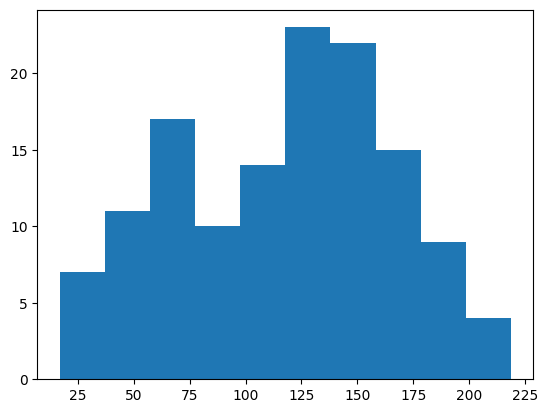

In [23]:
plt.hist(C[:, 0])

In [36]:
from scipy.optimize import linear_sum_assignment

row_ind, col_ind = linear_sum_assignment(C_thr)
costs = C_thr[row_ind, col_ind]

valid = costs < INF

matched_pred = row_ind[valid]
matched_gt = col_ind[valid]

unmatched_pred = np.setdiff1d(np.arange(pred_neg_pts[0].shape[0]), matched_pred)
unmatched_gt = np.setdiff1d(np.arange(neg_points[0].shape[0]), matched_gt)

In [39]:
print_info(matched_pred)
print_info(matched_gt)


: np.ndarray | shape=(18,) | dtype=int64

: np.ndarray | shape=(18,) | dtype=int64



In [40]:
print_info(unmatched_pred)

print_info(unmatched_gt)


: np.ndarray | shape=(114,) | dtype=int64

: np.ndarray | shape=(72,) | dtype=int64



In [41]:
TP_count = len(matched_pred)
FP_count = len(unmatched_pred)
FN_count = len(unmatched_gt)

In [42]:
TP_count

18

In [43]:
FP_count

114

In [44]:
FN_count

72